# Toy Model: Liouville / KDE Framework
## System: $dx/dt = x - x^3$

Self-contained demonstration of the probabilistic density-tracking framework
used in **Tseng et al. (2026, GRL)**, applied to a simple 1-D bistable ODE.

### Outline
1. System definition and phase portrait
2. Ensemble propagation (RK4)
3. Liouville density update (analytical divergence)
4. KDE reconstruction (standard and Liouville-weighted)
5. Shannon entropy evolution
6. Hovmöller PDF diagram
7. Snapshot comparison: uniform vs. Liouville KDE vs. true density

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde
from scipy.integrate import quad

rng = np.random.default_rng(42)

# ── global plot style ──────────────────────────────────────────────────
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12,
                     'axes.titlesize': 12, 'figure.dpi': 120})

---
## 1. System definition

$$v(x) = x - x^3, \qquad \text{div}(x) = \frac{\partial v}{\partial x} = 1 - 3x^2$$

Fixed points: $x^* = 0$ (unstable), $x^* = \pm 1$ (stable).

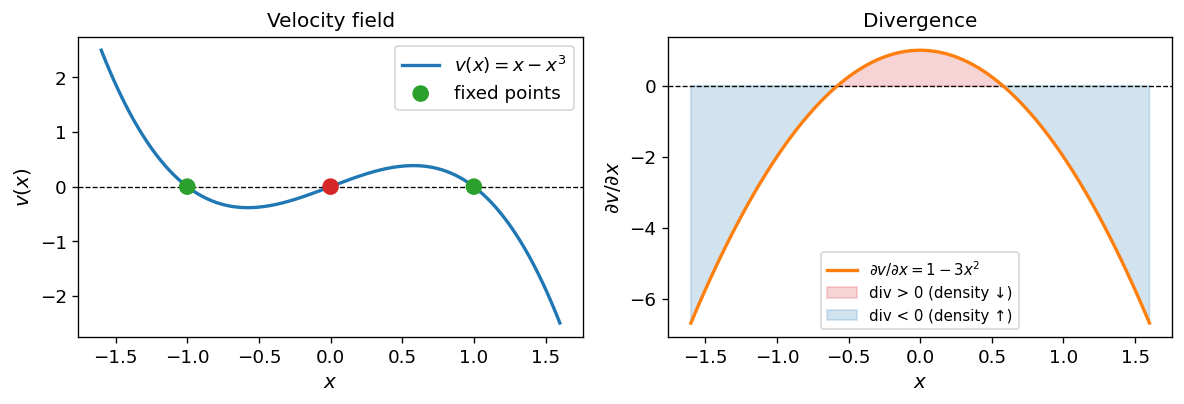

In [32]:
def v(x):
    """Velocity field:  dx/dt = x - x^3"""
    return x - x**3

def div_v(x):
    """Analytical divergence:  dv/dx = 1 - 3x^2"""
    return 1.0 - 3.0 * x**2

# ── phase portrait ─────────────────────────────────────────────────────
x_grid = np.linspace(-1.6, 1.6, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.plot(x_grid, v(x_grid), 'C0', lw=2, label=r'$v(x)=x-x^3$')
ax.scatter([-1, 0, 1], [0, 0, 0], s=80,
           color=['C2', 'C3', 'C2'], zorder=5,
           label='fixed points')
ax.set_xlabel('$x$'); ax.set_ylabel(r'$v(x)$')
ax.set_title('Velocity field'); ax.legend()

ax = axes[1]
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.plot(x_grid, div_v(x_grid), 'C1', lw=2, label=r'$\partial v/\partial x = 1-3x^2$')
ax.fill_between(x_grid, div_v(x_grid), 0,
                where=div_v(x_grid) > 0, alpha=0.2, color='C3',
                label='div > 0 (density ↓)')
ax.fill_between(x_grid, div_v(x_grid), 0,
                where=div_v(x_grid) < 0, alpha=0.2, color='C0',
                label='div < 0 (density ↑)')
ax.set_xlabel('$x$'); ax.set_ylabel(r'$\partial v/\partial x$')
ax.set_title('Divergence'); ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig('phase_portrait.png', bbox_inches='tight')
plt.show()

---
## 2. Ensemble propagation (RK4)

Initialise $N$ members from $\mathcal{N}(\mu_0,\,\sigma_0^2)$ near the
unstable fixed point and integrate with RK4.

In [33]:
# ── parameters ─────────────────────────────────────────────────────────
N       = 2000          # reference ensemble size
N_TEST  = 20            # sparse test ensemble (cf. paper's N=20 held-out test)
dt      = 0.02          # time step
T_end   = 4.0           # final time
T_steps = int(T_end / dt)
mu0     = 0.05          # initial mean (near unstable FP)
sig0    = 0.25          # initial spread

BW_DIV  = 2.0           # bandwidth multiplier for Eq. 9 divergence at members

# ── RK4 step ───────────────────────────────────────────────────────────
def rk4_step(x, dt):
    k1 = v(x)
    k2 = v(x + 0.5*dt*k1)
    k3 = v(x + 0.5*dt*k2)
    k4 = v(x + dt*k3)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# ── Eq. 9 divergence evaluated AT each member position ─────────────────
def div_Vbar_at_members(x_j, w_j, vdot_j, bw_factor=2.0):
    """
    Compute ∂V̄/∂X|_{X_j} via Eq. 9 of Tseng et al. (2026).
    Data-driven: requires only member positions X_j and velocities V_j.

    Two parts evaluated at each member X_j:
      Part 1: ∂J/∂X / ρ          (flux divergence)
      Part 2: −V̄_j ∂ρ/∂X / ρ   (advection)

    Returns shape (N,).
    Note: Scott bandwidth auto-widens for small N (N^{-1/5} factor).
    """
    h    = bw_factor * 1.06 * x_j.std() * len(x_j)**(-0.2)
    diff = x_j[:, None] - x_j[None, :]          # (N, N): X_j − X_m
    Kh   = np.exp(-0.5*(diff/h)**2) / (np.sqrt(2*np.pi)*h)
    dKh  = -(diff / h**2) * Kh

    rho_j  = Kh  @ w_j
    J_j    = Kh  @ (w_j * vdot_j)
    dJ_j   = dKh @ (w_j * vdot_j)
    drho_j = dKh @ w_j

    Vbar_j = J_j / rho_j
    return dJ_j / rho_j - Vbar_j * drho_j / rho_j   # ∂V̄/∂X|_{X_j}

# ── helper: integrate one ensemble with Eq. 9 KDE divergence ───────────
def integrate_ensemble(x0, bw_factor=BW_DIV):
    """
    Integrate positions forward with RK4; update Liouville weights via Eq. 9.
    Returns X_ens (T+1, N), W_kde (T+1, N).
    """
    n   = len(x0)
    X   = np.zeros((T_steps + 1, n))
    W   = np.zeros((T_steps + 1, n))
    lw  = np.zeros(n)
    X[0] = x0
    W[0] = np.ones(n) / n

    xc = x0.copy()
    for t in range(T_steps):
        xdot = v(xc)
        wc   = np.exp(lw - lw.max()); wc /= wc.sum()
        div  = div_Vbar_at_members(xc, wc, xdot, bw_factor=bw_factor)
        lw  += -div * dt
        xc   = rk4_step(xc, dt)
        X[t+1] = xc
        wr = np.exp(lw - lw.max()); W[t+1] = wr / wr.sum()
    return X, W

# ── reference ensemble (N=2000) ────────────────────────────────────────
x0      = rng.normal(mu0, sig0, N)
X_ens   = np.zeros((T_steps + 1, N))
W_ana   = np.zeros((T_steps + 1, N))   # analytical divergence (oracle)
W_kde   = np.zeros((T_steps + 1, N))   # KDE Eq. 9 (data-driven)

log_w_ana = np.zeros(N)
log_w_kde = np.zeros(N)
X_ens[0] = x0
W_ana[0] = W_kde[0] = np.ones(N) / N

x_cur = x0.copy()
for t in range(T_steps):
    xdot      = v(x_cur)
    div_ana   = div_v(x_cur)                              # oracle: 1 − 3x²
    wc_kde    = np.exp(log_w_kde - log_w_kde.max()); wc_kde /= wc_kde.sum()
    div_kde   = div_Vbar_at_members(x_cur, wc_kde, xdot, bw_factor=BW_DIV)

    log_w_ana += -div_ana * dt
    log_w_kde += -div_kde * dt
    x_cur      = rk4_step(x_cur, dt)
    X_ens[t+1] = x_cur
    wa = np.exp(log_w_ana - log_w_ana.max()); W_ana[t+1] = wa / wa.sum()
    wk = np.exp(log_w_kde - log_w_kde.max()); W_kde[t+1] = wk / wk.sum()

W_ens = W_ana   # alias for downstream cells

# ── sparse test ensemble (N_TEST = 20) — Eq. 9 only ───────────────────
x0_test          = rng.normal(mu0, sig0, N_TEST)
X_test, W_test   = integrate_ensemble(x0_test, bw_factor=BW_DIV)

t_arr = np.arange(T_steps + 1) * dt
print(f'Reference N={N}: max w_ana={W_ana[-1].max():.4f} | max w_kde={W_kde[-1].max():.4f}')
print(f'Sparse   N={N_TEST}: max w_test={W_test[-1].max():.4f}  '
      f'(Scott h ≈ {2.0*1.06*x0_test.std()*N_TEST**(-0.2):.3f})')

Reference N=2000: max w_ana=0.0125 | max w_kde=0.0013
Sparse   N=20: max w_test=0.0691  (Scott h ≈ 0.256)


---
## 3. KDE reconstruction (Liouville-weighted)

The density is reconstructed at each time step using the **Liouville-weighted KDE**:

$$\hat{\rho}_{\rm Liou}(x,t) = \sum_j w_j(t)\,K_h\!\left(x - x_j(t)\right)$$

Weights are **normalised across members** at every step ($\sum_j w_j = 1$):

$$w_j(t) \propto \exp\!\left(-\int_0^t \frac{\partial v}{\partial x}\!\Big|_{x_j}\,dt'\right)
= \exp\!\left(-\int_0^t (1 - 3x_j^2)\,dt'\right)$$

$K_h$ is a Gaussian kernel with Scott's-rule bandwidth $h = 1.06\,\hat\sigma\,N^{-1/5}$.

In [34]:
x_eval = np.linspace(-2.0, 2.0, 300)   # evaluation grid

def gaussian_kernel(x_eval, x_j, h):
    """Return (len(x_eval), len(x_j)) array of kernel values."""
    diff = x_eval[:, None] - x_j[None, :]      # (M, N)
    return np.exp(-0.5*(diff/h)**2) / (np.sqrt(2*np.pi)*h)

def scott_bandwidth(x_j):
    """Scott's rule bandwidth for sample x_j."""
    return 1.06 * x_j.std() * len(x_j)**(-0.2)

def kde_weighted(x_eval, x_j, w_j, h=None):
    """Liouville-weighted KDE.
    w_j must be normalised (sum = 1).
    h : float or None
        Bandwidth. If None, Scott's rule is applied to x_j.
        Pass a fixed h (e.g., from the reference ensemble) to make
        small-sample curves comparable to the large-sample reference.
    rho_hat(x) = sum_j  w_j * K_h(x - x_j)
    """
    if h is None:
        h = scott_bandwidth(x_j)               # adaptive (default)
    K = gaussian_kernel(x_eval, x_j, h)       # (M, N)
    return K @ w_j                             # (M,)

# ── select time snapshots ──────────────────────────────────────────────
snap_times = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]
snap_idx   = [int(round(tt / dt)) for tt in snap_times]

print('Snapshot indices:', list(zip(snap_times, snap_idx)))
print(f'Reference bandwidth at t=0 (N={N}):  h_ref = {scott_bandwidth(rng.normal(mu0,sig0,N)):.4f}')
print(f'Adaptive  bandwidth at t=0 (N={N_TEST}): h_test = {scott_bandwidth(rng.normal(mu0,sig0,N_TEST)):.4f}')

Snapshot indices: [(0.0, 0), (0.5, 25), (1.0, 50), (2.0, 100), (3.0, 150), (4.0, 200)]
Reference bandwidth at t=0 (N=2000):  h_ref = 0.0578
Adaptive  bandwidth at t=0 (N=20): h_test = 0.1241


---
## 4. Shannon entropy evolution

$$H(t) = -\int \hat{\rho}(x,t)\,\ln\hat{\rho}(x,t)\,dx
         \approx -\sum_k \hat{\rho}(x_k,t)\,\ln\hat{\rho}(x_k,t)\,\Delta x$$

$\Delta H(\tau) = H(\tau) - H(0)$ is anchored at $t=0$.

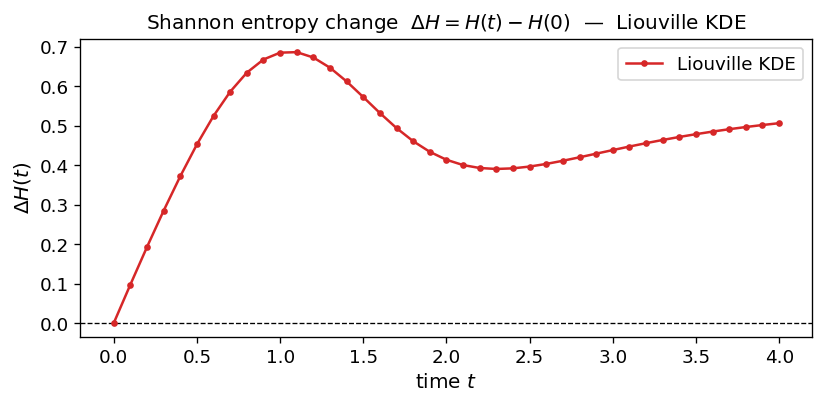

In [35]:
dx_eval = x_eval[1] - x_eval[0]

def shannon_entropy(rho, dx):
    """Numerical Shannon entropy from a 1-D density on a uniform grid."""
    r = rho[rho > 0]
    return -np.sum(r * np.log(r)) * dx

# ── compute entropy at every time step (Liouville KDE only) ───────────
stride = 5   # compute every `stride` steps to save time
t_ent  = []
H_liou = []

for t in range(0, T_steps + 1, stride):
    rho_l = kde_weighted(x_eval, X_ens[t], W_ens[t])
    t_ent.append(t_arr[t])
    H_liou.append(shannon_entropy(rho_l, dx_eval))

t_ent   = np.array(t_ent)
H_liou  = np.array(H_liou)
dH_liou = H_liou - H_liou[0]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.plot(t_ent, dH_liou, 'C3-o', ms=3, label='Liouville KDE')
ax.set_xlabel('time $t$')
ax.set_ylabel(r'$\Delta H(t)$')
ax.set_title(r'Shannon entropy change  $\Delta H = H(t) - H(0)$  —  Liouville KDE')
ax.legend()
fig.tight_layout()
plt.savefig('entropy_evolution.png', bbox_inches='tight')
plt.show()

---
## 5. Hovmöller PDF diagram

Density $\hat{\rho}(x,t)$ displayed as a 2-D colour field.
Ensemble member positions (sub-sampled) are overlaid as scatter dots
sized by their Liouville weight.

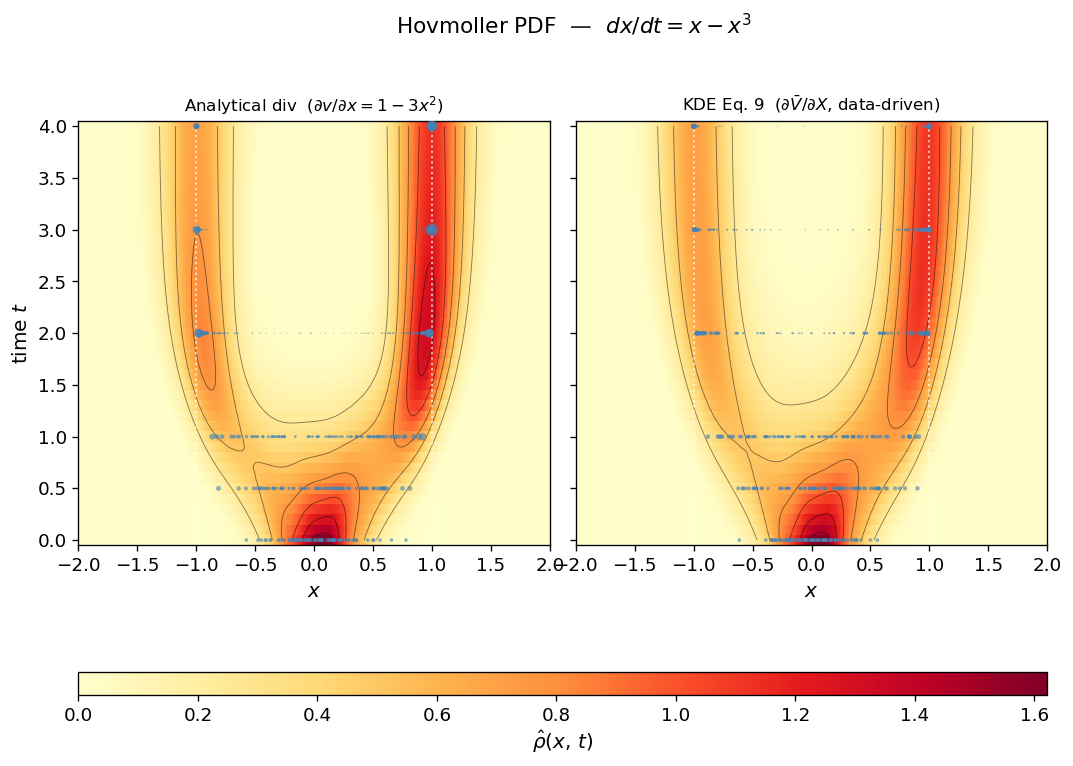

In [36]:
# ── build Hovmöller arrays — two divergence approaches ─────────────────
hov_stride = 5
hov_t_idx  = np.arange(0, T_steps + 1, hov_stride)
hov_t      = t_arr[hov_t_idx]

RHO_ana = np.zeros((len(hov_t_idx), len(x_eval)))   # analytical div weights
RHO_kde = np.zeros_like(RHO_ana)                     # KDE Eq. 9 weights

for k, ti in enumerate(hov_t_idx):
    RHO_ana[k] = kde_weighted(x_eval, X_ens[ti], W_ana[ti])
    RHO_kde[k] = kde_weighted(x_eval, X_ens[ti], W_kde[ti])

# ── scatter marker times ───────────────────────────────────────────────
mark_times = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]
mark_idx   = [int(round(tt / dt)) for tt in mark_times]
n_scatter  = 80

# shared weight scale across both panels and all mark times
all_w = np.concatenate([W_ana[ti] for ti in mark_idx] +
                       [W_kde[ti] for ti in mark_idx])
w_max = all_w.max()

def w_to_size(w, w_max, s_max=120):
    return s_max * (w / w_max)

# ── figure: two columns (analytical | KDE Eq. 9) ─────────────────────
_vmax = max(RHO_ana.max(), RHO_kde.max())
norm  = Normalize(vmin=0, vmax=_vmax)
cmap  = 'YlOrRd'

fig = plt.figure(figsize=(11, 6.5))
gs  = mgridspec.GridSpec(2, 3, figure=fig,
                         width_ratios=[1, 1, 0.06],
                         height_ratios=[1, 0.18],
                         wspace=0.08, hspace=0.40)

ax_ana  = fig.add_subplot(gs[0, 0])
ax_kde  = fig.add_subplot(gs[0, 1], sharey=ax_ana)
ax_cbar = fig.add_subplot(gs[1, :2])

for ax, RHO, W_sc, title in [
        (ax_ana, RHO_ana, W_ana,
         r'Analytical div  ($\partial v/\partial x = 1-3x^2$)'),
        (ax_kde, RHO_kde, W_kde,
         r'KDE Eq. 9  ($\partial\bar{V}/\partial X$, data-driven)')]:

    pc = ax.pcolormesh(x_eval, hov_t, RHO, cmap=cmap, norm=norm, shading='auto')
    ax.contour(x_eval, hov_t, RHO, levels=6, colors='k', linewidths=0.5, alpha=0.5)

    for ti, tt in zip(mark_idx, mark_times):
        xm      = X_ens[ti]
        wm      = W_sc[ti]
        idx_sub = rng.choice(N, size=min(n_scatter, N), replace=False)
        ax.scatter(xm[idx_sub], np.full(len(idx_sub), tt),
                   s=w_to_size(wm[idx_sub], w_max),
                   c='steelblue', marker='o', alpha=0.6,
                   linewidths=0, zorder=3)

    ax.set_xlim(x_eval[[0, -1]])
    ax.set_xlabel('$x$')
    ax.set_ylabel('time $t$')
    ax.set_title(title, fontsize=10)
    ax.axvline(-1, color='w', ls=':', lw=1.2, alpha=0.7)
    ax.axvline( 1, color='w', ls=':', lw=1.2, alpha=0.7)

plt.setp(ax_kde.get_yticklabels(), visible=False)
ax_kde.set_ylabel('')

# ── narrow colourbar ───────────────────────────────────────────────────
fig.draw_without_rendering()
_cp  = ax_cbar.get_position()
_h30 = _cp.height * 0.30
_y30 = _cp.y0 + (_cp.height - _h30) * 0.5
ax_cbar.set_position([_cp.x0, _y30, _cp.width, _h30])
cb = fig.colorbar(pc, cax=ax_cbar, orientation='horizontal')
cb.set_label(r'$\hat{\rho}(x,\,t)$', labelpad=2)

fig.suptitle(r'Hovmoller PDF  —  $dx/dt = x - x^3$', y=1.02, fontsize=13)
plt.savefig('hovmoller.png', bbox_inches='tight')
plt.show()

---
## 6. Snapshot comparison

At selected times, compare:
* **Uniform KDE** (grey) — ignores density change along trajectories
* **Liouville KDE** (red) — correctly accounts for convergence/divergence
* **Histogram** (light bars) — empirical reference

At late times the Liouville KDE sharpens near $x = \pm 1$ because
$\text{div} < 0$ there, accumulating probability density.

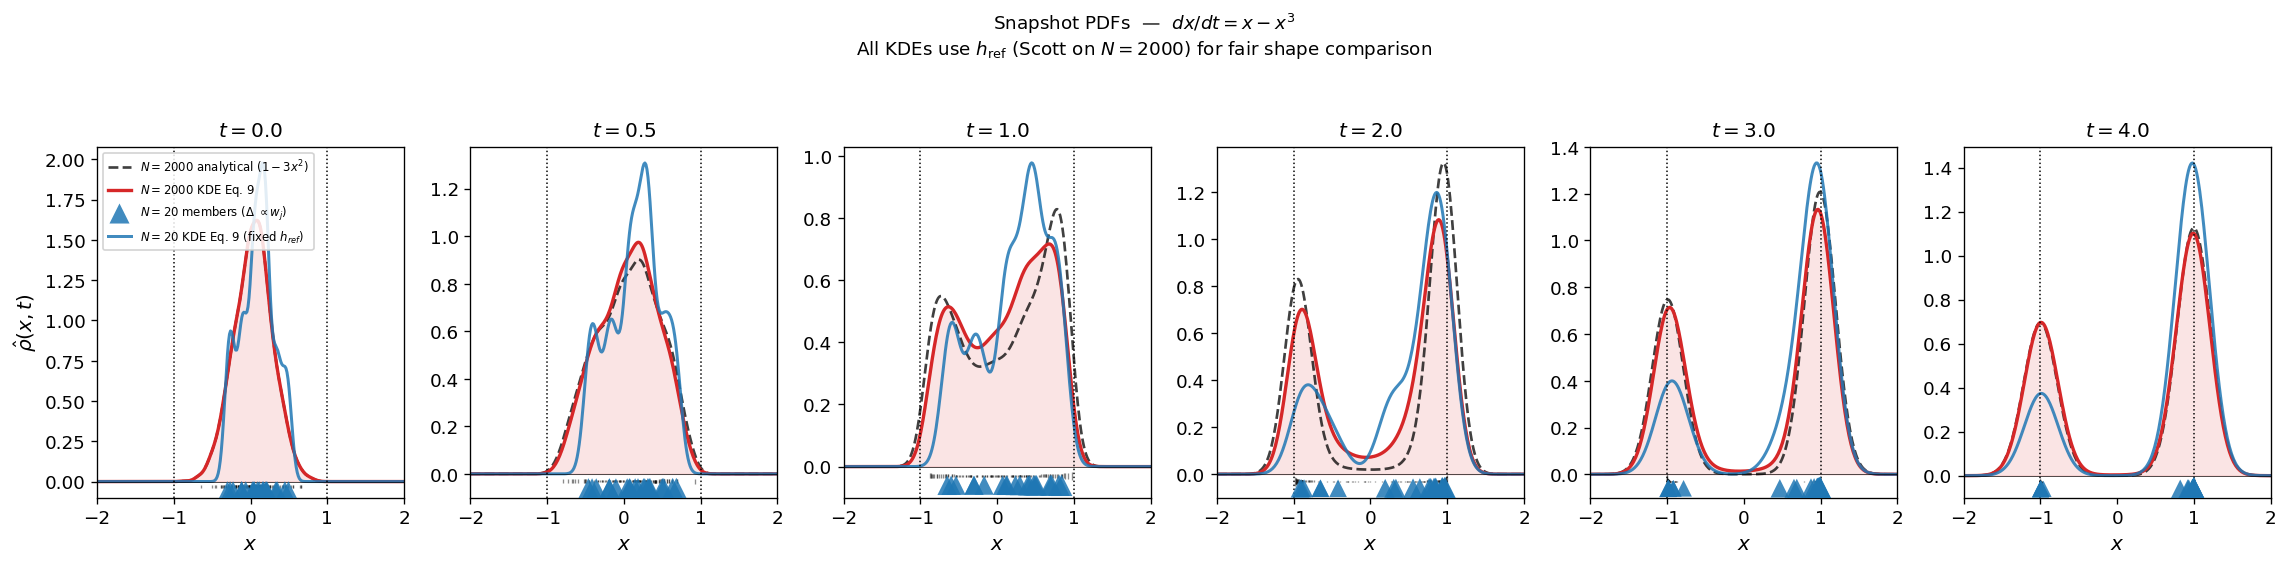

In [37]:
n_cols = len(snap_times)
fig, axes = plt.subplots(1, n_cols, figsize=(3.2*n_cols, 4.5),
                         sharey=False, sharex=True)

# ── shared scatter size scales ─────────────────────────────────────────
all_w_ana  = np.concatenate([W_ana[ti]  for ti in snap_idx])
all_w_test = np.concatenate([W_test[ti] for ti in snap_idx])
w_ana_max  = all_w_ana.max()
w_test_max = all_w_test.max()
S_MAX      = 80
S_MAX_TEST = 200

for ax, ti, tt in zip(axes, snap_idx, snap_times):
    x_cur  = X_ens[ti]
    x_test = X_test[ti]
    w_ana  = W_ana[ti]
    w_kde  = W_kde[ti]
    w_test = W_test[ti]

    # ── reference bandwidth from N=2000 at this time step ─────────────
    # Use it for BOTH the N=2000 and N=20 KDEs → fair shape comparison
    h_ref = scott_bandwidth(x_cur)             # from N=2000 ensemble

    rho_ana  = kde_weighted(x_eval, x_cur,  w_ana,  h=h_ref)
    rho_kde  = kde_weighted(x_eval, x_cur,  w_kde,  h=h_ref)
    rho_test = kde_weighted(x_eval, x_test, w_test, h=h_ref)  # fixed h

    # ── N=2000 analytical scatter (rug) ───────────────────────────────
    idx_sub = rng.choice(N, size=min(120, N), replace=False)
    s_rug   = S_MAX * (w_ana[idx_sub] / w_ana_max)
    ax.scatter(x_cur[idx_sub], np.full(len(idx_sub), -0.03),
               s=s_rug, c='k', marker='|', alpha=0.45,
               linewidths=0.8, zorder=4)

    # ── N=2000 analytical KDE (oracle, dashed reference) ──────────────
    ax.plot(x_eval, rho_ana, 'k--', lw=1.6, alpha=0.75,
            label=rf'$N={N}$ analytical ($1-3x^2$)')

    # ── N=2000 KDE Eq.9 (data-driven) ────────────────────────────────
    ax.plot(x_eval, rho_kde, 'C3-', lw=2.0,
            label=rf'$N={N}$ KDE Eq. 9')
    ax.fill_between(x_eval, rho_kde, alpha=0.12, color='C3')

    # ── N=20 sparse test: member scatter (triangles) ──────────────────
    s_test = S_MAX_TEST * (w_test / w_test_max)
    ax.scatter(x_test, np.full(N_TEST, -0.06),
               s=s_test, c='C0', marker='^', alpha=0.85,
               linewidths=0, zorder=5,
               label=rf'$N={N_TEST}$ members ($\Delta$ $\propto w_j$)')

    # ── N=20 KDE Eq.9, evaluated with SAME h as N=2000 ────────────────
    ax.plot(x_eval, rho_test, 'C0-', lw=1.8, alpha=0.85,
            label=rf'$N={N_TEST}$ KDE Eq. 9 (fixed $h_{{ref}}$)')

    ax.axvline(-1, color='k', ls=':', lw=0.9)
    ax.axvline( 1, color='k', ls=':', lw=0.9)
    ax.axhline(0,  color='k', lw=0.4)
    ax.set_xlabel('$x$')
    ax.set_title(f'$t = {tt}$')
    ax.set_xlim(-2, 2)
    ax.set_ylim(bottom=-0.10)

axes[0].set_ylabel(r'$\hat{\rho}(x,t)$')
axes[0].legend(fontsize=7, loc='upper left', framealpha=0.85)

fig.suptitle(r'Snapshot PDFs  —  $dx/dt = x - x^3$'
             '\n'
             r'All KDEs use $h_{\rm ref}$ (Scott on $N=2000$) for fair shape comparison',
             fontsize=11, y=1.04)
fig.tight_layout()
plt.savefig('snapshots.png', bbox_inches='tight')
plt.show()

---
## 7. Divergence decomposition: analytical vs KDE-derived (Eq. 9)

The Liouville equation in projected 1-D feature space is (main text Eq. 2):

$$\frac{\partial\rho}{\partial t} + \frac{\partial}{\partial X}\bigl[\rho\,\overline{V}\bigr] = 0,
\qquad \overline{V}(X,t)=\mathbb{E}\!\left[\tfrac{dX}{dt}\,\middle|\,X\right]$$

Shannon entropy tendency depends on the **divergence of the conditional mean velocity** $\partial\overline{V}/\partial X$ (Eq. 5).  Expanding the flux derivative gives **two contributions**:

$$\frac{\partial\overline{V}}{\partial X} =
  \underbrace{\frac{1}{\rho}\frac{\partial J}{\partial X}}_{\substack{\text{Part 1} \\ \text{flux divergence}}}
\;-\;
  \underbrace{\frac{\overline{V}}{\rho}\frac{\partial\rho}{\partial X}}_{\substack{\text{Part 2} \\ \text{advection}}}$$

where $J(X,t)=\sum_m w_m V_m\,K_h(X-X_m)$ is the probability flux.  
Using $\partial K_h(X-X_m)/\partial X = -(X-X_m)/h^2\cdot K_h$, both parts combine into **Eq. 9** of Tseng et al. (2026):

$$\boxed{\frac{\partial\overline{V}}{\partial X}\bigg|_{X_j}
= \frac{\displaystyle\sum_m [\overline{V}_j - V_m]\;\frac{X_j-X_m}{h^2}\;K_h(X_j-X_m)}
       {\displaystyle\sum_m K_h(X_j-X_m)}}$$

**Part 1 alone is insufficient**: the previous cell used only $-\partial\rho/\partial t\,/\,\rho$, which omits the advection correction. Both parts together should recover the analytical $1-3x^2$.

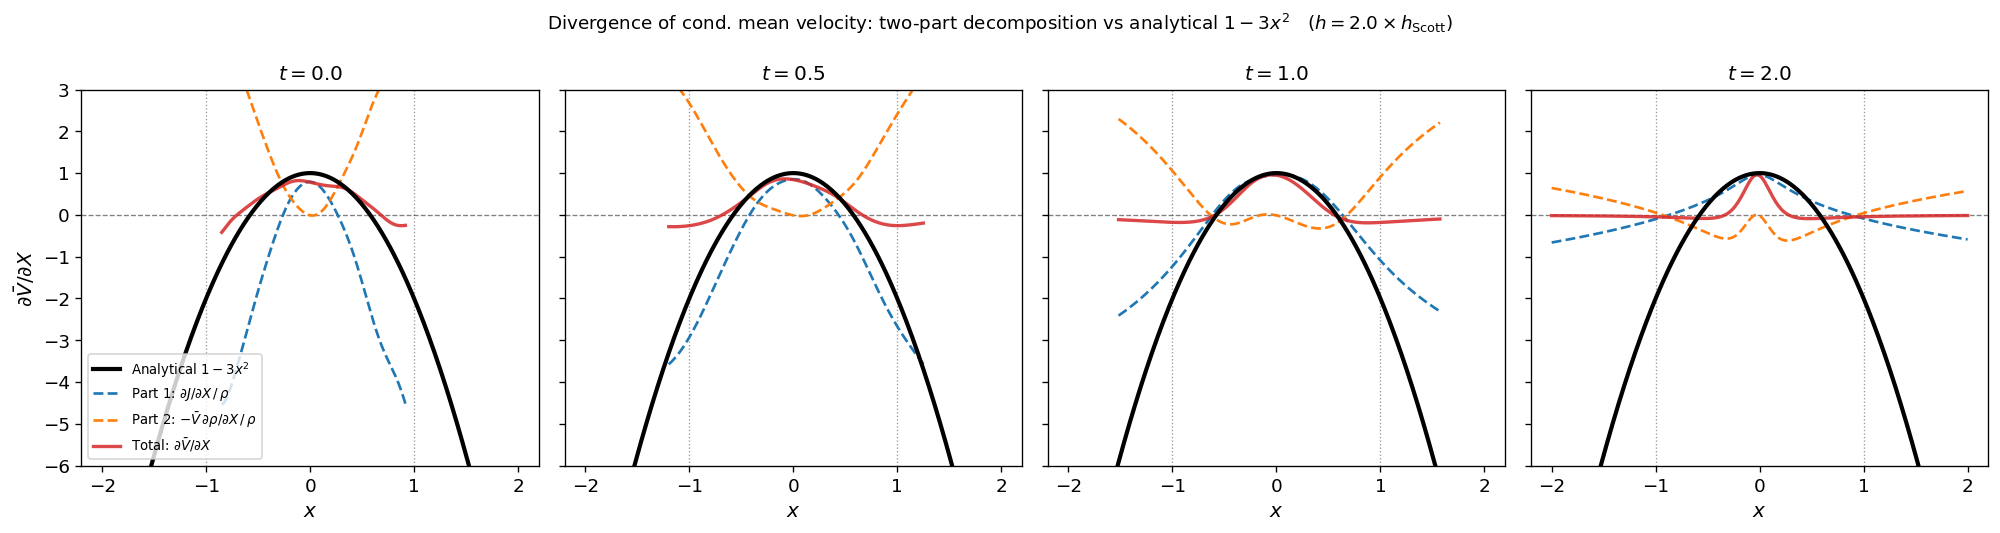

In [38]:
def compute_div_Vbar(x_eval, x_j, w_j, vdot_j, bw_factor=2.0):
    """
    Compute ∂V̄/∂X at x_eval via Eq. 9 of Tseng et al. (2026).

    Two-part decomposition:
      Part 1 — flux divergence :  ∂J/∂X  / ρ
      Part 2 — advection       : −V̄  ∂ρ/∂X / ρ
      Total  = Part 1 + Part 2 = ∂V̄/∂X

    where:
      ρ(x)  = Σ_m w_m K_h(x−X_m)                (Liouville KDE)
      J(x)  = Σ_m w_m V_m K_h(x−X_m)            (probability flux)
      V̄(x) = J / ρ                               (cond. mean velocity)
      ∂K_h(x−X_m)/∂x = −(x−X_m)/h² · K_h(x−X_m)

    Parameters
    ----------
    bw_factor : float
        Multiplier on Scott's bandwidth (default 2.0 for smoother divergence).

    Returns
    -------
    div_total, part1, part2, Vbar  — each shape (M,), NaN outside density support
    """
    h_scott = 1.06 * x_j.std() * len(x_j)**(-0.2)
    h       = bw_factor * h_scott                        # wider kernel

    diff    = x_eval[:, None] - x_j[None, :]            # (M, N): x − X_m
    Kh      = np.exp(-0.5*(diff/h)**2) / (np.sqrt(2*np.pi)*h)
    dKh_dx  = -(diff / h**2) * Kh                       # ∂K_h/∂x  (M, N)

    rho      = Kh     @ w_j                             # (M,)
    drho_dx  = dKh_dx @ w_j                             # (M,) = ∂ρ/∂x
    J        = Kh     @ (w_j * vdot_j)                  # (M,)
    dJ_dx    = dKh_dx @ (w_j * vdot_j)                  # (M,) = ∂J/∂x

    mask  = rho > 5e-3 * rho.max()
    Vbar  = np.where(mask, J / rho, np.nan)

    part1 = np.where(mask,  dJ_dx / rho,          np.nan)   # flux divergence
    part2 = np.where(mask, -Vbar * drho_dx / rho, np.nan)   # advection
    div_total = part1 + part2

    return div_total, part1, part2, Vbar


# ── analytical divergence on evaluation grid ───────────────────────────
div_analytic = div_v(x_eval)   # 1 − 3x²

# ── four-panel comparison at increasing lead times ─────────────────────
check_times = [0.0, 0.5, 1.0, 2.0]
BW_FACTOR   = 2.0              # wider than Scott → smoother divergence estimate

fig, axes = plt.subplots(1, len(check_times), figsize=(4.2*len(check_times), 4.5),
                         sharey=True, sharex=True)

for ax, t_check in zip(axes, check_times):
    ti    = int(round(t_check / dt))
    x_now = X_ens[ti]
    w_now = W_ens[ti]
    xdot  = v(x_now)

    div_total, part1, part2, Vbar = compute_div_Vbar(
        x_eval, x_now, w_now, xdot, bw_factor=BW_FACTOR)

    ax.axhline(0,  color='gray', lw=0.8, ls='--')
    ax.axvline(-1, color='k',    lw=0.8, ls=':',  alpha=0.4)
    ax.axvline( 1, color='k',    lw=0.8, ls=':',  alpha=0.4)

    ax.plot(x_eval, div_analytic, 'k-',   lw=2.5, zorder=5,
            label=r'Analytical $1-3x^2$')
    ax.plot(x_eval, part1,        'C0--', lw=1.6,
            label=r'Part 1: $\partial J/\partial X\,/\,\rho$')
    ax.plot(x_eval, part2,        'C1--', lw=1.6,
            label=r'Part 2: $-\bar{V}\,\partial\rho/\partial X\,/\,\rho$')
    ax.plot(x_eval, div_total,    'C3-',  lw=2.0, alpha=0.85,
            label=r'Total: $\partial\bar{V}/\partial X$')

    ax.set_title(f'$t = {t_check}$')
    ax.set_xlabel('$x$')
    ax.set_ylim(-6, 3)

axes[0].set_ylabel(r'$\partial\bar{V}/\partial X$', fontsize=12)
axes[0].legend(fontsize=8, loc='lower left')

h_label = rf'$h = {BW_FACTOR}\times h_{{\rm Scott}}$'
fig.suptitle(r'Divergence of cond. mean velocity: two-part decomposition vs analytical $1-3x^2$'
             f'   ({h_label})',
             fontsize=11)
fig.tight_layout()
plt.savefig('divergence_comparison.png', bbox_inches='tight')
plt.show()

---
## 8. Summary

| Step | Key equation | Code cell |
|---|---|---|
| Define system | $v(x)=x-x^3$, $\partial v/\partial x=1-3x^2$ | §1 |
| Ensemble integration | RK4 | §2 |
| Liouville weight update | $\rho_j(t+\Delta t)=\rho_j(t)\exp(-\text{div}_j\,\Delta t)$ | §2 |
| KDE density | Gaussian kernel, Scott bandwidth | §3 |
| Entropy | $H=-\int\rho\ln\rho\,dx$ | §4 |
| Hovmöller | 2-D color field + scatter overlay | §5 |
| Snapshot compare | uniform vs Liouville KDE | §6 |
| SI cross-check | analytical $\partial\hat{\rho}/\partial t$ vs FD | §7 |

The Liouville KDE correctly tracks probability concentration near the
stable fixed points $x=\pm 1$ (where $\text{div}<0$), whereas the
uniform KDE systematically under-estimates the peak density at late times.
This is the central diagnostic in Tseng et al. (2026, GRL).